# CH 6 — Rule Data Mining as a Specification Search : Parameter Optimization

## Objectif pédagogique

Ce notebook explique l’idée suivante :

> **L’optimisation des paramètres est la forme la plus étroite du data mining : on garde la même règle de trading, mais on teste plusieurs valeurs numériques pour trouver celles qui maximisent la performance historique.**

Dans le cadre EBTA, cette notion est cruciale parce qu’elle montre que même une recherche apparemment “simple” peut déjà créer du **biais de minage de données**.

Le danger n’est pas seulement de tester une mauvaise idée.

Le danger est de tester tellement de réglages qu’un résultat chanceux finit presque forcément par apparaître.

## 1. L’idée centrale

Dans le **rule data mining**, on cherche une spécification de règle.

Autrement dit, on cherche une formule logique capable de transformer des données de marché en signaux exploitables.

Exemple simple :

> Acheter quand une moyenne mobile courte passe au-dessus d’une moyenne mobile longue.

Cette règle possède une **forme fixe** :

$$
\text{Signal}_t =
\begin{cases}
1 & \text{si } MA_{\text{courte},t} > MA_{\text{longue},t} \\
0 & \text{sinon}
\end{cases}
$$

L’optimisation des paramètres ne change pas cette forme.

Elle change seulement les valeurs numériques :

- moyenne courte = 10, 20, 30 jours ;
- moyenne longue = 50, 100, 200 jours ;
- seuil RSI = 30, 35, 40 ;
- stop-loss = $1\%$, $2\%$, $3\%$.

> **L’Eurêka : optimiser un paramètre, ce n’est pas inventer une nouvelle règle. C’est faire varier les boutons d’une règle déjà définie.**

## 2. Vision EBTA

En EBTA, il faut toujours distinguer deux choses :

| Élément | Signification |
|---|---|
| **Forme de la règle** | La logique générale du signal |
| **Paramètres** | Les valeurs numériques utilisées par cette logique |
| **Espace de recherche** | Toutes les combinaisons testées |
| **Figure de mérite** | Le score utilisé pour choisir le meilleur réglage |
| **Biais de minage de données** | La surestimation créée par la sélection du meilleur résultat historique |

L’optimisation des paramètres est donc une procédure de sélection.

On ne demande pas :

> “Est-ce que cette règle marche ?”

On demande plutôt :

> “Parmi tous les réglages testés, lequel a donné le meilleur résultat historique ?”

La nuance est énorme.

Si tu testes 100 combinaisons, tu donnes au hasard 100 occasions de produire une performance séduisante.

## 3. Taille de l’espace de recherche

Si une règle possède plusieurs paramètres, la taille de l’espace de recherche est le produit du nombre de valeurs testées pour chaque paramètre.

Exemple :

- 10 valeurs possibles pour la moyenne courte ;
- 10 valeurs possibles pour la moyenne longue ;
- 5 valeurs possibles pour un filtre de volatilité.

Alors :

$$
N_{\text{tests}} = 10 \times 10 \times 5 = 500
$$

Ce nombre est fondamental.

> **Plus $N_{\text{tests}}$ augmente, plus le risque de sélectionner un faux champion augmente.**

In [1]:
# Exemple : calculer la taille d'un espace de recherche

short_ma_values = list(range(5, 55, 5))      # 5, 10, ..., 50
long_ma_values = list(range(60, 260, 20))    # 60, 80, ..., 240
volatility_filters = [0.5, 1.0, 1.5, 2.0]

n_tests = len(short_ma_values) * len(long_ma_values) * len(volatility_filters)

print("Nombre de valeurs pour la moyenne courte :", len(short_ma_values))
print("Nombre de valeurs pour la moyenne longue :", len(long_ma_values))
print("Nombre de filtres de volatilité :", len(volatility_filters))
print("Taille totale de l'espace de recherche :", n_tests)

Nombre de valeurs pour la moyenne courte : 10
Nombre de valeurs pour la moyenne longue : 10
Nombre de filtres de volatilité : 4
Taille totale de l'espace de recherche : 400


## 4. Exemple complet : optimisation brute-force d’un croisement de moyennes mobiles

Nous allons créer une série de prix fictive, puis tester plusieurs couples :

$$
(MA_{\text{courte}}, MA_{\text{longue}})
$$

La règle sera volontairement simple :

- position longue si $MA_{\text{courte}} > MA_{\text{longue}}$ ;
- sinon, position neutre ;
- la performance est mesurée par le rendement cumulé.

Ce n’est pas un conseil de trading.

C’est un laboratoire pédagogique pour comprendre la logique de l’optimisation.

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Création d'une série de prix fictive
n_days = 800
daily_returns = np.random.normal(loc=0.0002, scale=0.01, size=n_days)
prices = 100 * np.exp(np.cumsum(daily_returns))

data = pd.DataFrame({
    "price": prices
})

data["market_return"] = data["price"].pct_change().fillna(0)

data.head()

,price,market_return
0,100.518051,0.000000
1,100.399245,-0.001182
2,101.071842,0.006699
3,102.643505,0.015550
4,102.423926,-0.002139


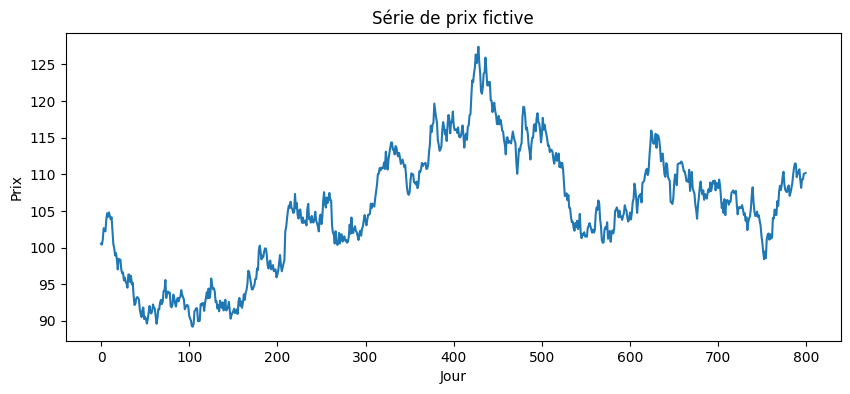

In [47]:
# Visualisation du prix fictif

plt.figure(figsize=(10, 4))
plt.plot(data["price"])
plt.title("Série de prix fictive")
plt.xlabel("Jour")
plt.ylabel("Prix")
plt.show()

In [48]:
def backtest_moving_average_crossover(data, short_window, long_window):
    '''
    Backtest pédagogique d'un croisement de moyennes mobiles.

    Règle :
    - Long si moyenne courte > moyenne longue
    - Neutre sinon

    Le signal est décalé d'un jour pour éviter le look-ahead bias.
    '''
    df = data.copy()

    df["short_ma"] = df["price"].rolling(short_window).mean()
    df["long_ma"] = df["price"].rolling(long_window).mean()

    df["signal"] = (df["short_ma"] > df["long_ma"]).astype(int)
    df["position"] = df["signal"].shift(1).fillna(0)

    df["strategy_return"] = df["position"] * df["market_return"]

    cumulative_return = (1 + df["strategy_return"]).prod() - 1
    average_daily_return = df["strategy_return"].mean()
    volatility = df["strategy_return"].std()

    sharpe_like = np.nan
    if volatility > 0:
        sharpe_like = average_daily_return / volatility * np.sqrt(252)

    return {
        "short_window": short_window,
        "long_window": long_window,
        "cumulative_return": cumulative_return,
        "average_daily_return": average_daily_return,
        "volatility": volatility,
        "sharpe_like": sharpe_like
    }

In [49]:
# Recherche brute-force : on teste toutes les combinaisons autorisées

short_windows = range(5, 55, 5)
long_windows = range(60, 260, 20)

results = []

for short_window in short_windows:
    for long_window in long_windows:
        result = backtest_moving_average_crossover(
            data=data,
            short_window=short_window,
            long_window=long_window
        )
        results.append(result)

results_df = pd.DataFrame(results)

# Tri par performance cumulée
ranked_results = results_df.sort_values("cumulative_return", ascending=False)

ranked_results.head(10)

,short_window,long_window,cumulative_return,average_daily_return,volatility,sharpe_like
1,5,80,0.283772,0.000336,0.006885,0.774563
11,10,80,0.234799,0.000288,0.006972,0.655498
73,40,120,0.202995,0.000256,0.007112,0.571983
83,45,120,0.201726,0.000255,0.007126,0.568122
23,15,120,0.185817,0.000237,0.006993,0.539034
21,15,80,0.181004,0.000233,0.007017,0.526028
92,50,100,0.177750,0.000230,0.007098,0.513556
24,15,140,0.169750,0.000221,0.007083,0.495340
34,20,140,0.169583,0.000221,0.007040,0.497307
14,10,140,0.164557,0.000216,0.007137,0.480083


In [50]:
best = ranked_results.iloc[0]

print("Meilleur réglage trouvé :")
print("Moyenne courte :", int(best["short_window"]))
print("Moyenne longue :", int(best["long_window"]))
print("Rendement cumulé :", round(best["cumulative_return"] * 100, 2), "%")
print("Sharpe-like :", round(best["sharpe_like"], 2))
print("Nombre total de tests :", len(results_df))

Meilleur réglage trouvé :
Moyenne courte : 5
Moyenne longue : 80
Rendement cumulé : 28.38 %
Sharpe-like : 0.77
Nombre total de tests : 100


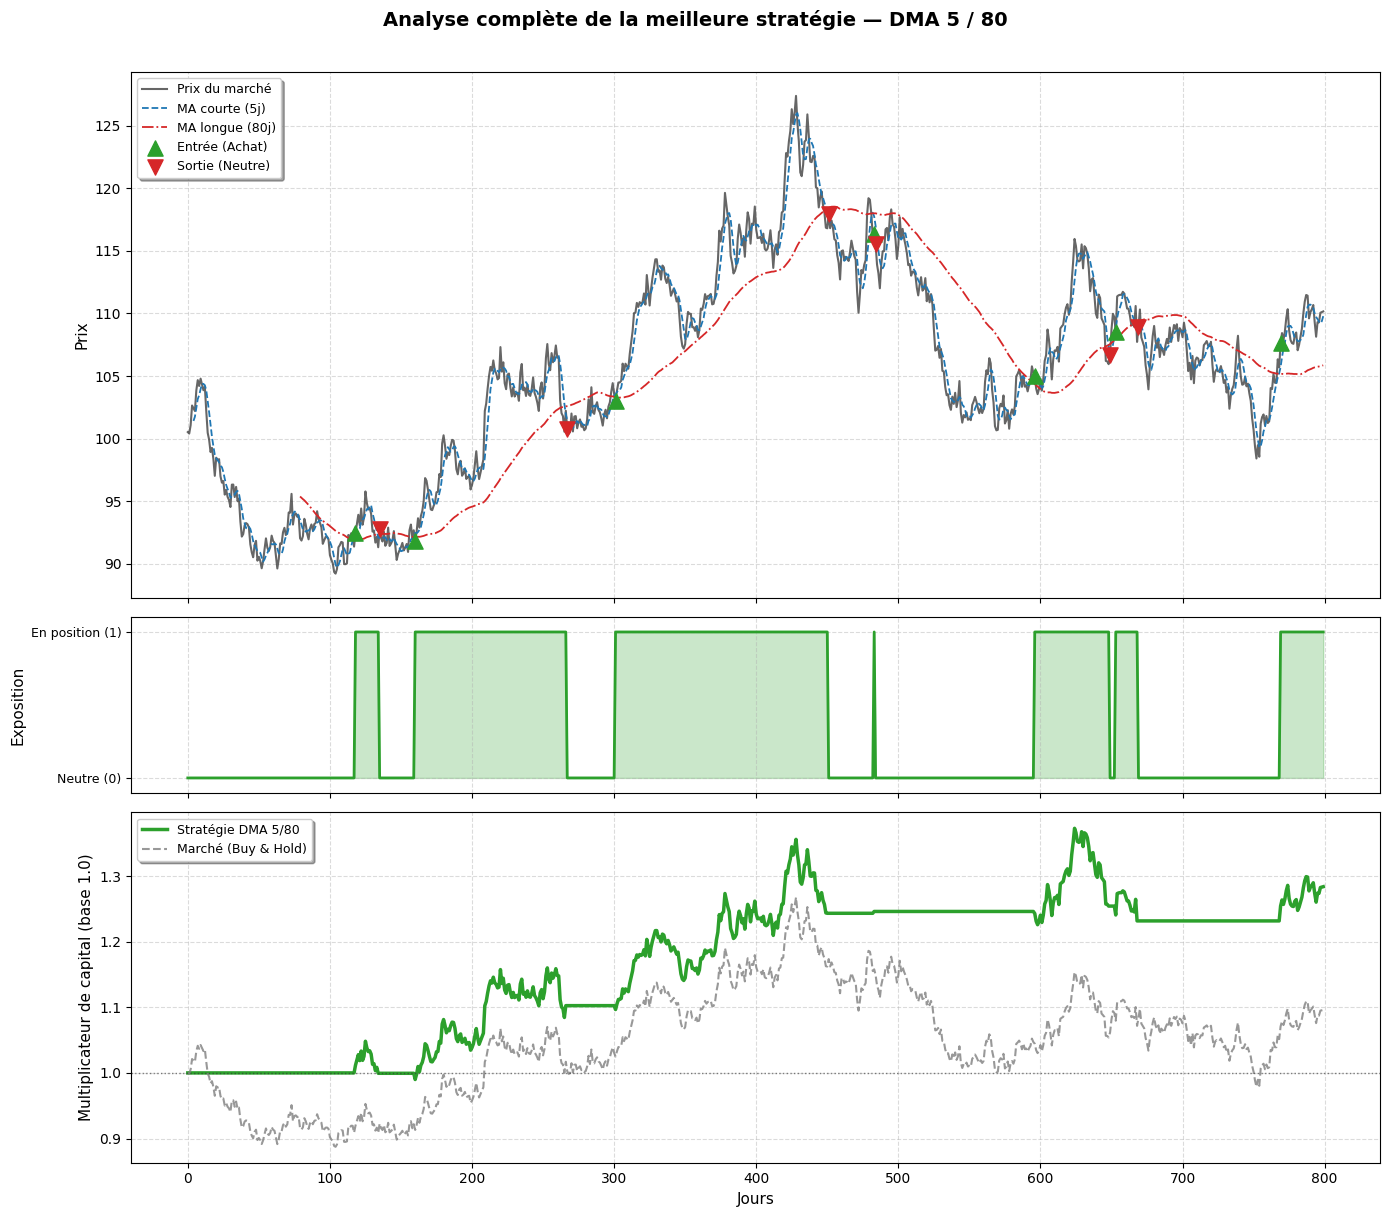

In [51]:
# ── 1. Paramètres & calculs ──────────────────────────────────────────────────
best_short = int(best["short_window"])
best_long  = int(best["long_window"])

df_best = data.copy()
df_best["short_ma"]        = df_best["price"].rolling(best_short).mean()
df_best["long_ma"]         = df_best["price"].rolling(best_long).mean()
df_best["signal"]          = (df_best["short_ma"] > df_best["long_ma"]).astype(int)
df_best["position"]        = df_best["signal"].shift(1).fillna(0)
df_best["strategy_return"] = df_best["position"] * df_best["market_return"]
df_best["equity_curve"]    = (1 + df_best["strategy_return"]).cumprod()
df_best["market_equity"]   = (1 + df_best["market_return"]).cumprod()

# Détection des changements de position (signaux d'entrée / sortie)
df_best["buy_trigger"]  = (df_best["position"] == 1) & (df_best["position"].shift(1) == 0)
df_best["sell_trigger"] = (df_best["position"] == 0) & (df_best["position"].shift(1) == 1)

buy_signals  = df_best[df_best["buy_trigger"]]
sell_signals = df_best[df_best["sell_trigger"]]

# ── 2. Figure à 3 panneaux ───────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,
    figsize=(14, 12),
    sharex=True,
    dpi=100,
    gridspec_kw={"height_ratios": [3, 1, 2]}
)
fig.suptitle(
    f"Analyse complète de la meilleure stratégie — DMA {best_short} / {best_long}",
    fontsize=14, fontweight="bold", y=1.01
)

# ── Panneau 1 : Prix + Moyennes Mobiles + Signaux ───────────────────────────
ax1.plot(df_best["price"],    label="Prix du marché",              color="#333333", alpha=0.75, linewidth=1.5)
ax1.plot(df_best["short_ma"], label=f"MA courte ({best_short}j)",  color="#1f77b4", linestyle="--", linewidth=1.3)
ax1.plot(df_best["long_ma"],  label=f"MA longue ({best_long}j)",   color="#d62728", linestyle="-.", linewidth=1.3)

ax1.scatter(buy_signals.index,  buy_signals["price"],
            color="#2ca02c", marker="^", s=120, zorder=5, label="Entrée (Achat)")
ax1.scatter(sell_signals.index, sell_signals["price"],
            color="#d62728", marker="v", s=120, zorder=5, label="Sortie (Neutre)")

ax1.set_ylabel("Prix", fontsize=11)
ax1.legend(loc="upper left", frameon=True, shadow=True, fontsize=9)
ax1.grid(True, linestyle="--", alpha=0.45)

# ── Panneau 2 : Exposition (0 / 1) ──────────────────────────────────────────
ax2.fill_between(df_best.index, df_best["position"],
                 color="#2ca02c", alpha=0.25, label="Exposé au marché")
ax2.plot(df_best["position"], color="#2ca02c", linewidth=2)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["Neutre (0)", "En position (1)"], fontsize=9)
ax2.set_ylabel("Exposition", fontsize=11)
ax2.set_ylim(-0.1, 1.1)
ax2.grid(True, linestyle="--", alpha=0.45)

# ── Panneau 3 : Equity Curve ─────────────────────────────────────────────────
ax3.plot(df_best["equity_curve"],  label=f"Stratégie DMA {best_short}/{best_long}",
         color="#2ca02c", linewidth=2.5)
ax3.plot(df_best["market_equity"], label="Marché (Buy & Hold)",
         color="#7f7f7f", linestyle="--", alpha=0.8, linewidth=1.5)
ax3.axhline(1.0, color="#333333", linestyle=":", linewidth=1, alpha=0.6)

ax3.set_ylabel("Multiplicateur de capital (base 1.0)", fontsize=11)
ax3.set_xlabel("Jours", fontsize=11)
ax3.legend(loc="upper left", frameon=True, shadow=True, fontsize=9)
ax3.grid(True, linestyle="--", alpha=0.45)

plt.tight_layout()
plt.show()


## 5. Pourquoi ce meilleur résultat peut être trompeur

Le meilleur réglage historique peut donner l’impression d’avoir découvert une règle supérieure.

Mais il faut poser la question EBTA :

> **Ce résultat est-il dû à un vrai pouvoir prédictif, ou simplement au fait que nous avons testé beaucoup de réglages ?**

Quand on choisit le maximum parmi plusieurs résultats, ce maximum est naturellement gonflé.

Formellement, si chaque configuration $i$ a une performance observée :

$$
P_i = \mu_i + \epsilon_i
$$

où :

- $\mu_i$ est la vraie performance attendue ;
- $\epsilon_i$ est la chance d’échantillonnage.

L’optimisation choisit :

$$
P_{\max} = \max(P_1, P_2, ..., P_N)
$$

Le problème est que le maximum sélectionne souvent une configuration qui a bénéficié d’un $\epsilon_i$ positif.

> **L’Eurêka : le meilleur paramètre historique est souvent le paramètre qui a reçu le plus gros cadeau du hasard.**

In [52]:
# Simulation pédagogique : même si toutes les règles n'ont aucun talent,
# le meilleur résultat parmi beaucoup de tests peut sembler impressionnant.

np.random.seed(123)

n_rules = 200
true_skill = 0.0
random_noise = np.random.normal(loc=0, scale=1, size=n_rules)

observed_scores = true_skill + random_noise

best_score = observed_scores.max()
average_score = observed_scores.mean()

print("Score moyen des règles :", round(average_score, 3))
print("Meilleur score observé :", round(best_score, 3))
print("Nombre de règles testées :", n_rules)

Score moyen des règles : 0.004
Meilleur score observé : 2.598
Nombre de règles testées : 200


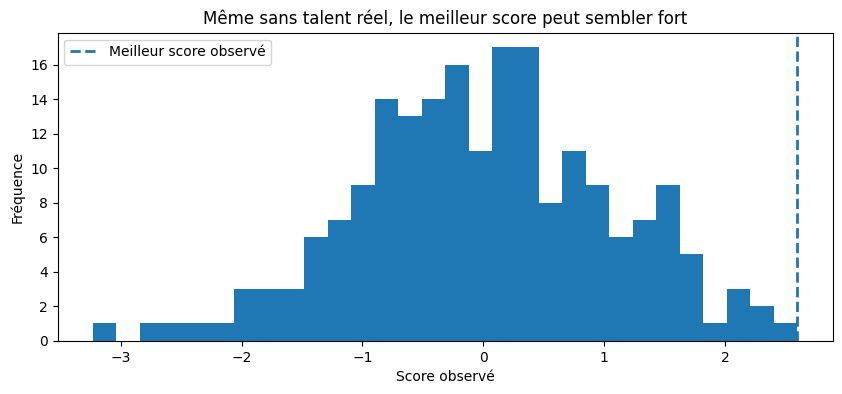

In [53]:
plt.figure(figsize=(10, 4))
plt.hist(observed_scores, bins=30)
plt.axvline(best_score, linestyle="--", linewidth=2, label="Meilleur score observé")
plt.title("Même sans talent réel, le meilleur score peut sembler fort")
plt.xlabel("Score observé")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

## 6. Effet du nombre de tests sur le faux champion

Maintenant, répétons l’expérience avec plusieurs tailles d’univers.

Nous allons simuler des règles sans talent réel.

Puis nous allons observer le meilleur score obtenu quand on teste :

- 10 règles ;
- 50 règles ;
- 100 règles ;
- 500 règles ;
- 1 000 règles.

Si le hasard est seul à l’œuvre, la moyenne reste proche de zéro.

Mais le meilleur score augmente avec le nombre de tests.

In [54]:
np.random.seed(456)

search_sizes = [10, 50, 100, 500, 1000]
n_simulations = 1000

summary = []

for size in search_sizes:
    best_scores = []

    for _ in range(n_simulations):
        scores = np.random.normal(loc=0, scale=1, size=size)
        best_scores.append(scores.max())

    summary.append({
        "n_tests": size,
        "average_best_score": np.mean(best_scores),
        "median_best_score": np.median(best_scores),
        "p95_best_score": np.percentile(best_scores, 95)
    })

summary_df = pd.DataFrame(summary)
summary_df

,n_tests,average_best_score,median_best_score,p95_best_score
0,10,1.547817,1.497940,2.547096
1,50,2.259637,2.207063,3.077238
2,100,2.487166,2.442207,3.256349
3,500,3.045628,3.013972,3.747704
4,1000,3.241178,3.175848,3.925989


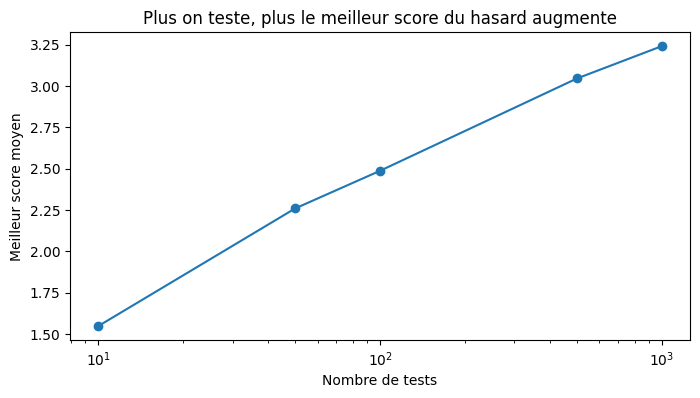

In [55]:
plt.figure(figsize=(8, 4))
plt.plot(summary_df["n_tests"], summary_df["average_best_score"], marker="o")
plt.title("Plus on teste, plus le meilleur score du hasard augmente")
plt.xlabel("Nombre de tests")
plt.ylabel("Meilleur score moyen")
plt.xscale("log")
plt.show()

## 7. Brute-force vs algorithmes génétiques

Il existe deux grandes manières d’explorer l’espace de recherche.

| Méthode | Principe | Avantage | Limite |
|---|---|---|---|
| **Brute-force** | Tester toutes les combinaisons | Simple, complet, transparent | Peut devenir très lent |
| **Algorithme génétique** | Tester, sélectionner, recombiner, muter | Efficace sur grands espaces | Plus complexe à documenter |

La recherche brute-force est idéale quand l’espace est petit.

Mais si tu as :

$$
50 \times 50 \times 20 \times 10 = 500\,000
$$

combinaisons, tester tout peut devenir lourd.

Les **algorithmes génétiques** servent alors à guider la recherche vers les zones prometteuses.

Mais attention :

> **Une méthode intelligente ne supprime pas le biais de minage de données. Elle rend seulement la recherche plus efficace.**

Même si l’ordinateur trouve vite un bon réglage, il faut toujours corriger le fait qu’il a cherché parmi plusieurs possibilités.

## 8. Checklist EBTA avant d’optimiser des paramètres

Avant de lancer une optimisation, documente toujours :

| Question | Pourquoi c’est important |
|---|---|
| Quelle est la forme fixe de la règle ? | Pour éviter de mélanger plusieurs idées |
| Quels paramètres sont optimisés ? | Pour connaître les degrés de liberté |
| Combien de valeurs sont testées par paramètre ? | Pour mesurer la taille de l’univers |
| Quelle figure de mérite est maximisée ? | Pour savoir ce que l’ordinateur cherche vraiment |
| Combien de tests au total ? | Pour estimer le risque de faux champion |
| Les résultats proches sont-ils corrélés ? | Pour comprendre si les réglages sont presque identiques |
| Une validation out-of-sample est-elle prévue ? | Pour tester la robustesse |
| Une correction du data mining bias est-elle prévue ? | Pour éviter de croire au hasard |

Cette checklist est simple, mais elle empêche de tomber dans le piège classique :

> “J’ai trouvé le meilleur paramètre, donc ma stratégie est valide.”

Non.

Le bon raisonnement est :

> “J’ai trouvé le meilleur paramètre historique. Maintenant je dois estimer combien de cette performance vient de la chance de sélection.”

## 9. Mini-framework Python pour documenter une optimisation

Dans une approche EBTA, le résultat brut ne suffit pas.

Il faut aussi produire une fiche de recherche qui garde la trace du protocole.

In [56]:
research_log = {
    "rule_family": "Dual Moving Average Crossover",
    "fixed_logic": "Long if short moving average is above long moving average",
    "optimized_parameters": {
        "short_window": list(short_windows),
        "long_window": list(long_windows)
    },
    "figure_of_merit": "cumulative_return",
    "number_of_tests": len(results_df),
    "best_short_window": int(best["short_window"]),
    "best_long_window": int(best["long_window"]),
    "best_cumulative_return_percent": round(best["cumulative_return"] * 100, 2),
    "warning": "Historical best parameter may be inflated by data mining bias."
}

research_log

{'rule_family': 'Dual Moving Average Crossover',
 'fixed_logic': 'Long if short moving average is above long moving average',
 'optimized_parameters': {'short_window': [5,
   10,
   15,
   20,
   25,
   30,
   35,
   40,
   45,
   50],
  'long_window': [60, 80, 100, 120, 140, 160, 180, 200, 220, 240]},
 'figure_of_merit': 'cumulative_return',
 'number_of_tests': 100,
 'best_short_window': 5,
 'best_long_window': 80,
 'best_cumulative_return_percent': np.float64(28.38),
 'warning': 'Historical best parameter may be inflated by data mining bias.'}

## 10. Synthèse finale

L’optimisation des paramètres est la première forme de data mining parce qu’elle consiste à chercher le meilleur réglage dans une famille de règles déjà définie.

Elle est utile parce qu’elle rend la recherche systématique.

Mais elle est dangereuse parce qu’elle sélectionne naturellement les résultats les plus favorables du passé.

> **L’Eurêka final : l’ordinateur ne trouve pas forcément le paramètre le plus vrai. Il trouve le paramètre qui a le mieux gagné dans l’échantillon testé. La mission EBTA est ensuite de séparer le talent réel du cadeau du hasard.**

La vraie discipline consiste donc à :

- définir la règle avant de tester ;
- compter toutes les combinaisons ;
- documenter la recherche ;
- éviter de croire naïvement au meilleur résultat ;
- valider hors-échantillon ;
- corriger le biais de minage de données lorsque c’est nécessaire.

## Annexe — Source originale collée


### **CH 6 : RULE DATA MINING AS A SPECIFICATION SEARCH - PARAMETER OPTIMIZATION**

Cette section définit le minage de données comme une recherche rigoureuse de spécifications et détaille sa forme la plus courante et la plus étroite : l'optimisation des paramètres.

---

#### **Idées clés :**
*   **Chasse aux spécifications :** Le minage de données est une quête pour identifier les opérations mathématiques et logiques qui transforment les données de prix en profits maximaux.
*   **Optimisation des paramètres :** C'est la forme la plus restreinte de minage de données, où la forme de la règle est fixe et seules les valeurs numériques changent.
*   **Espace de recherche :** L'univers des solutions est défini par le produit de toutes les combinaisons de paramètres testées.
*   **Méthodes de recherche :** On distingue la recherche "brute-force" (exhaustive) des méthodes intelligentes comme les algorithmes génétiques.

---

#### **Référence :**
*Rule Data Mining as a Specification Search* / *Types of Searches: Parameter Optimization* (Pages 265–266).

---

#### **Citation Directe :**
« The narrowest form of data mining is parameter optimization. Here, the search universe is confined to rules with the same form differing only in terms of their parameter values. » (Page 266).

---

#### **Vision Macro :**
L'enjeu est de remplacer l'intuition par une sélection systématique. David Aronson explique que le minage de données ne consiste pas à "espérer" un signal, mais à "chasser" activement la configuration mathématique exacte qui a le mieux fonctionné. En limitant la recherche à l'optimisation de paramètres, le trader accepte une structure logique préétablie (ex: une tendance) et laisse l'ordinateur trouver le réglage de précision (le "fine-tuning") pour maximiser la figure de mérite.

---

#### **Vision Micro :**
Le mécanisme de l'optimisation de paramètres repose sur trois piliers techniques :

1.  **La structure logique fixe :** La règle conserve la même syntaxe. Par exemple, une règle de croisement de moyennes mobiles (Dual-Moving-Average Crossover) reste toujours un croisement, peu importe les périodes choisies.
2.  **La recherche exhaustive (Brute-Force) :** L'ordinateur teste chaque combinaison possible de paramètres. Si on teste 10 valeurs pour la moyenne courte et 10 pour la moyenne longue, le minage de données porte sur 100 tests.
3.  **L'optimisation intelligente (Algorithmes Génétiques) :** Inspirée de l'évolution biologique, cette méthode utilise les résultats des premiers tests pour guider les suivants. Elle est particulièrement efficace lorsque le nombre de combinaisons est trop élevé pour une recherche exhaustive ou lorsque les données sont très bruitées.

---

#### **Résumé Simplifié :**
L'optimisation des paramètres, c'est comme avoir une recette de cuisine où les ingrédients sont fixes (par exemple, un gâteau au chocolat), mais où vous essayez toutes les quantités possibles de sucre et tous les temps de cuisson pour trouver la version que les gens préfèrent. Vous ne changez pas la nature du plat, seulement les dosages numériques.

---

#### **Exemple du livre pour mieux comprendre :**
*   **La règle de croisement de moyennes mobiles :** Aronson utilise l'exemple d'une règle qui achète quand une moyenne courte croise une moyenne longue. L'optimisation consiste à tester si un réglage (26 jours, 55 jours) est meilleur qu'un réglage (27 jours, 55 jours). Ces règles sont très corrélées car elles sont presque identiques, ce qui réduit un peu le biais de minage de données par rapport à des règles totalement différentes.

---

#### **Actions Concrètes :**
*   **Définir la forme de la règle :** Avant de lancer l'ordinateur, fixez la logique (ex: RSI, Moyennes Mobiles) pour éviter une recherche trop éparpillée.
*   **Calculer la taille de l'univers :** Multipliez le nombre de paramètres testés pour savoir combien de "coups de chance" potentiels vous offrez au hasard.
*   **Utiliser les algorithmes génétiques :** Si vous avez des milliers de combinaisons, privilégiez cette méthode pour gagner du temps et de la précision.
*   **Documenter le processus :** Notez le nombre total de tests effectués, car c'est cette donnée qui permettra de corriger le biais de minage de données final.

---

#### **À retenir absolument :**
*   C'est la forme de recherche la plus **basique** de l'AT objective.
*   L'optimisation ne crée pas de nouvelles idées, elle **ajuste des réglages**.
*   Plus vous testez de paramètres, plus le **biais de minage de données** augmente.
*   Les **algorithmes génétiques** sont l'outil de choix pour les espaces de recherche complexes.
*   Le succès passé d'un paramètre **surestime** presque toujours son profit futur.

J'ai terminé l'analyse de l'optimisation des paramètres comme type de recherche selon le protocole EBTA.
```